In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor

### Add mbt-gym to path

In [2]:
import sys
sys.path.append("../")

In [3]:
from mbt_gym.agents.BaselineAgents import CarteaJaimungalMmAgent
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.wrappers import *
from mbt_gym.rewards.RewardFunctions import PnL, CjMmCriterion
from mbt_gym.stochastic_processes.midprice_models import BrownianMotionMidpriceModel
from mbt_gym.stochastic_processes.arrival_models import PoissonArrivalModel
from mbt_gym.stochastic_processes.fill_probability_models import ExponentialFillFunction
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics

### Create market making environment

In [4]:
import sys
sys.path.append("../") # This version of the notebook is in the subfolder "notebooks" of the repo

import gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from copy import deepcopy


from mbt_gym.agents.BaselineAgents import *
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.helpers.plotting import *
from mbt_gym.stochastic_processes.midprice_models import *
from mbt_gym.stochastic_processes.arrival_models import *
from mbt_gym.stochastic_processes.fill_probability_models import *
import torch
#print(torch.cuda.is_available())
#print(torch.cuda.get_device_name())
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics
seed = 50


## Replication of Avellaneda Stoikov result with ArithmeticBrownianMotionWithFadsMidpriceModel and FadsInformedUniformedTradersArrivalModel (fads_propportion=0 and psi=0)

In [5]:
from mbt_gym.stochastic_processes.midprice_models import ArithmeticBrownianMotionWithFadsMidpriceModel

### Parameters

In [ ]:
initial_price = 100
terminal_time = 1.0
sigma = 1.0
n_steps = 1000
initial_inventory = 0
fill_exponent = 0
fads_proportion = 0
eta = 10
baseline_arrival_rate = np.array([[0.0, 0.0]])
phi = 15
psi = 15
k = 1
gamma = k
alpha=0.001
mu=0

In [7]:
def get_as_env(num_trajectories:int = 1):
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories)
    arrival_model = FadsInformedUniformedTradersArrivalModel(baseline_arrival_rate=baseline_arrival_rate,
                                                step_size=terminal_time/n_steps,
                                                phi=phi,
                                                psi=psi,
                                                k=k,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma)
    fill_probability_model = ExponentialFillFunction(fill_exponent=fill_exponent, 
                                                     step_size=1/n_steps,
                                                     num_trajectories=num_trajectories)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      max_inventory=n_steps,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [8]:
as_env = get_as_env()

In [9]:
as_agent = MMwithFadsInformedUniformedTradersAgent(risk_aversion=0.1, env=as_env)
print(as_env.model_dynamics
      .midprice_model)


/Users/andrea/Desktop/gitProject/mbt_gym/Experiments_MMwithFadsInfUninfTraders/../mbt_gym/agents/BaselineAgents.py:260: UserWarning: MM agent is quoting a negative spread
  warnings.warn("MM agent is quoting a negative spread")


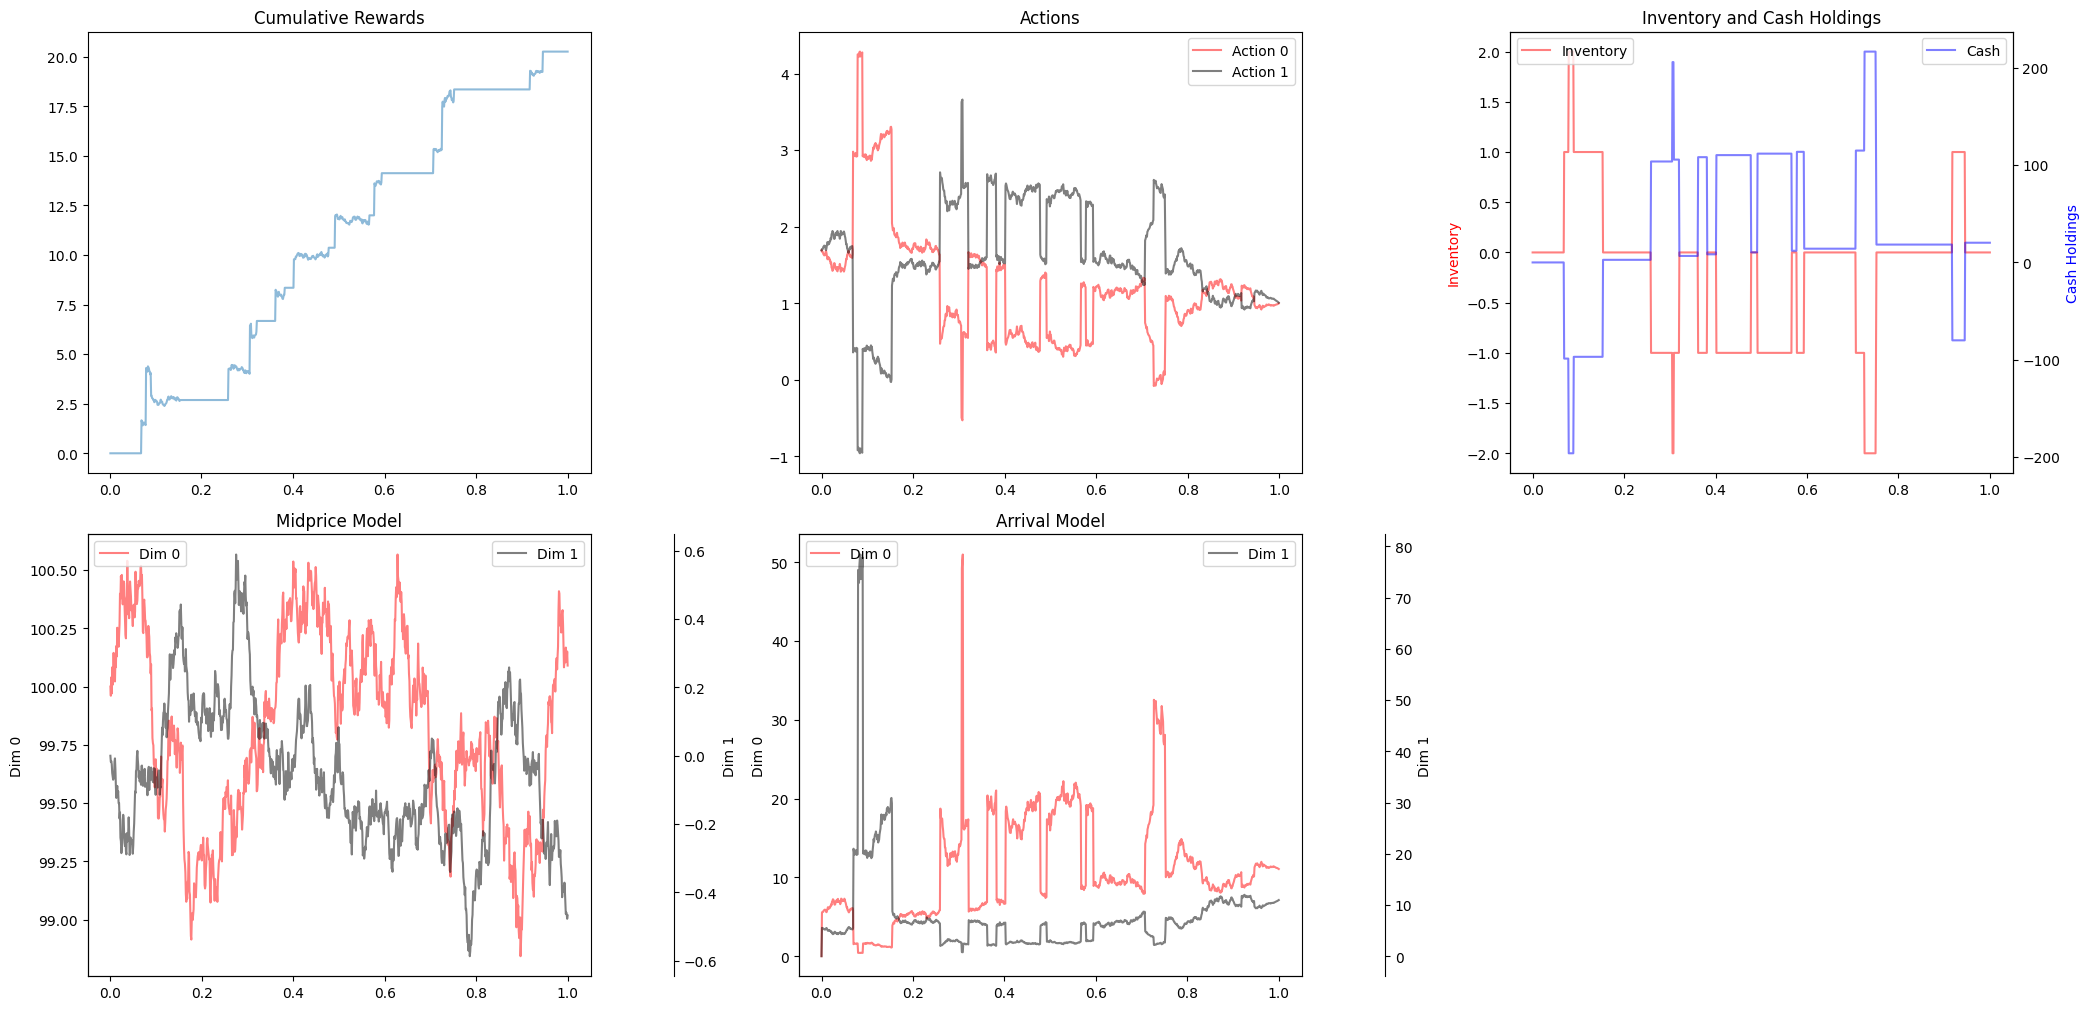

In [10]:
plot_trajectory_extended(as_env, as_agent)

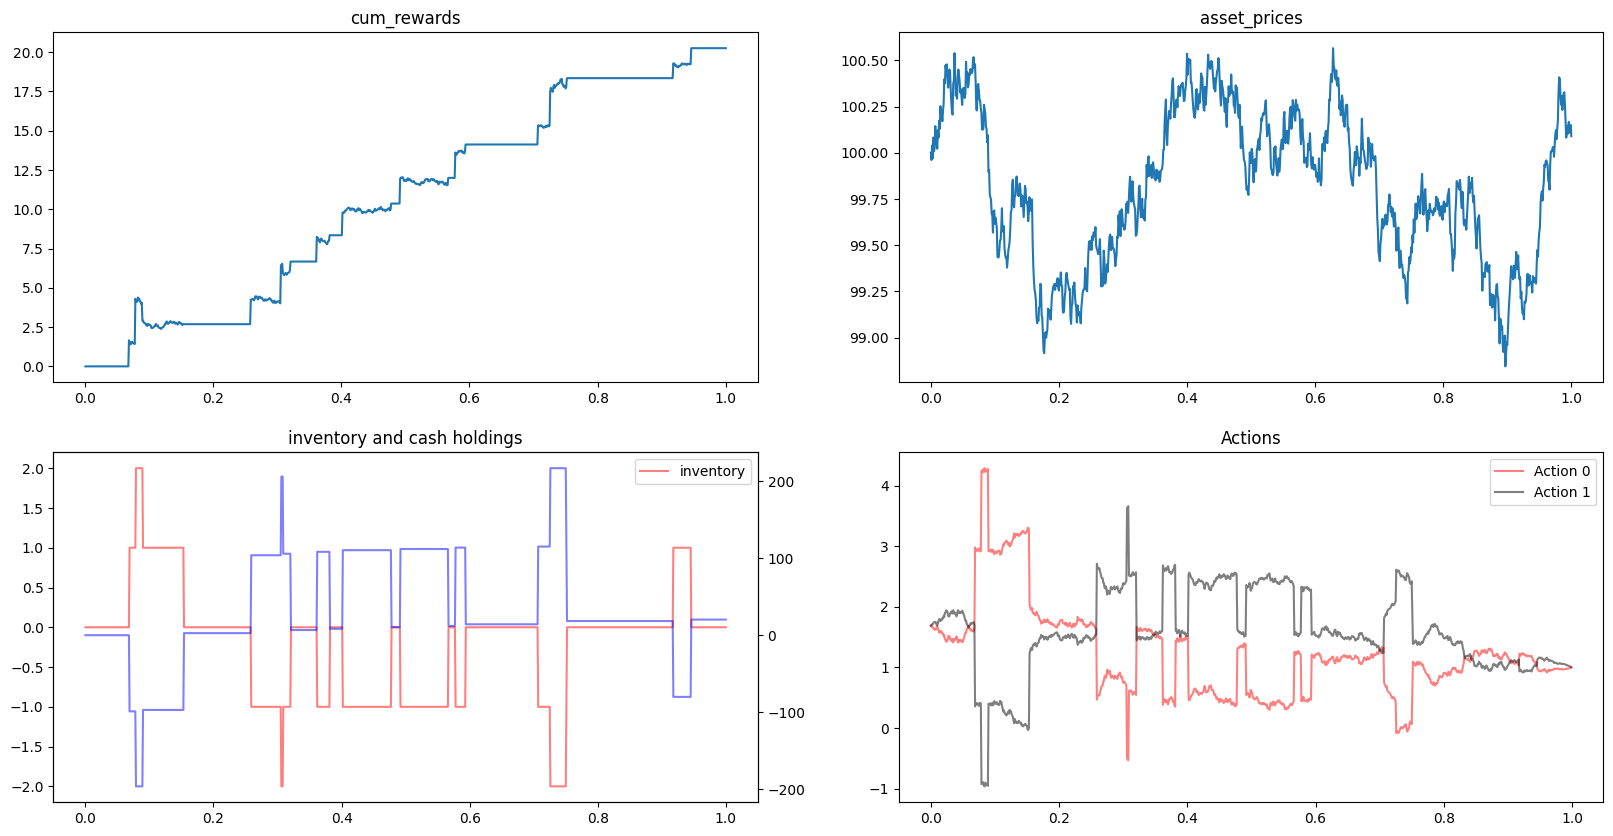

In [11]:
plot_trajectory(as_env, as_agent, seed = 50)

In [ ]:
num_trajectories = 1000
vec_env = get_as_env(num_trajectories)
vec_as = MMwithFadsInformedUniformedTradersAgent(risk_aversion=0.1, alpha=alpha, mu = mu, eta=eta, gamma=gamma, phi=phi, psi=psi, k=k, sigma=sigma, fads_proportion=fads_proportion, env=vec_env)

print(vec_env.model_dynamics
      .midprice_model)

In [13]:
observations, actions, rewards = generate_trajectory(vec_env, vec_as)

In [14]:
results, fig, total_rewards = generate_results_table_and_hist(vec_env=vec_env,agent=vec_as)

In [15]:
results

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.270061,20.626151,5.406255,-0.037,1.802118
